# 🫁 Comparative Deep Learning Study: Chest X-Ray Pneumonia Detection

## Academic Project — EfficientNetB0 & MobileNetV2: Feature Extraction vs End-to-End Classification

---

### Project Overview
This notebook presents a rigorous comparative study of two deep learning paradigms applied to pneumonia detection from chest X-rays:

- **Approach 1**: Deep Learning Feature Extraction + Traditional ML Classifiers (SVM, Logistic Regression)
- **Approach 2**: End-to-End Deep Learning Classification with Fine-Tuning

Both approaches are evaluated using **EfficientNetB0** and **MobileNetV2** as backbone architectures.

### Notebook Sections
1. Reproducibility Setup
2. Library Installation & Imports
3. Dataset Loading & Analysis
4. Dataset Metadata Export
5. Preprocessing & Data Splitting
6. Data Augmentation
7. Approach 1 — Feature Extraction + ML Classifiers
8. Approach 2 — End-to-End Deep Learning + Fine-Tuning
9. Bonus — MobileNetV2 Comparison
10. Evaluation & Comparative Analysis
11. Visualizations
12. Conclusion

---
> **Dataset**: [Chest X-Ray Pneumonia — Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

## Section 1 — Reproducibility Setup

Reproducibility is **critical in medical AI** for the following reasons:
- Clinical validation requires consistent, repeatable results across different hardware and sessions
- Regulatory approval (FDA, CE) demands reproducible model behavior
- Scientific integrity demands that published results can be independently verified
- Model debugging and improvement require stable baselines

We fix seeds for **Python's random module**, **NumPy**, and **TensorFlow**, and enable **deterministic operations** to eliminate non-determinism from GPU parallelism.

In [2]:
import os
import random
import numpy as np
import tensorflow as tf

# ─── Global Seed ────────────────────────────────────────────────────────────
# A fixed seed ensures that every random operation (weight initialization,
# data shuffling, dropout masks, augmentation) produces the SAME sequence
# of numbers on every run — making results fully reproducible.
SEED = 42

# Python's built-in hash randomization (affects dict ordering, set iteration)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Python's random module — used by augmentation helpers
random.seed(SEED)

# NumPy — used for array shuffling, data splits, and metric calculations
np.random.seed(SEED)

# TensorFlow — controls weight initialization, dropout, and layer stochasticity
tf.random.set_seed(SEED)

# Deterministic operations: forces TF to use only deterministic CUDA kernels.
# This eliminates floating-point non-determinism from GPU parallelism, which
# can cause small but accumulating differences across runs.
# NOTE: This may slightly reduce GPU throughput — acceptable for research.
tf.config.experimental.enable_op_determinism()

print(f"✅ All random seeds fixed to {SEED}")
print(f"✅ TensorFlow deterministic operations enabled")
print(f"✅ TensorFlow version: {tf.__version__}")

✅ All random seeds fixed to 42
✅ TensorFlow deterministic operations enabled
✅ TensorFlow version: 2.20.0


## Section 2 — Library Installation & Imports

In [3]:
# Install required packages (Colab-compatible)
!pip install -q kagglehub openpyxl

In [4]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os, random, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
warnings.filterwarnings('ignore')

# ─── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# ─── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Kaggle Dataset ─────────────────────────────────────────────────────────
import kagglehub

# ─── Excel Output ───────────────────────────────────────────────────────────
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ─── Global Hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 10
LEARNING_RATE = 0.001
IMG_SIZE     = (224, 224)
IMG_SHAPE    = (224, 224, 3)
NUM_CLASSES  = 2
CLASS_NAMES  = ['NORMAL', 'PNEUMONIA']

# Output directory for saving all artefacts
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ All libraries imported successfully")
print(f"   GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ All libraries imported successfully
   GPU available: True


## Section 3 — Dataset Loading & Analysis

In [5]:
# ─── Download Dataset via KaggleHub ─────────────────────────────────────────
# kagglehub handles authentication automatically using your Kaggle credentials
# stored in ~/.kaggle/kaggle.json or KAGGLE_* environment variables.

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [6]:
# ─── Locate Dataset Root ────────────────────────────────────────────────────
dataset_root = Path(path)

# The dataset ships with predefined train/val/test splits; we will
# ignore those boundaries and re-split to guarantee 70/15/15.
# This avoids the heavily imbalanced original validation set.

def collect_images(root: Path):
    """
    Recursively collect all JPEG/PNG images under `root`.
    Returns a DataFrame with columns: [file_path, label, split].
    The 'split' column reflects the ORIGINAL folder name for reference.
    """
    records = []
    for split_folder in ['train', 'val', 'test']:
        split_path = root / 'chest_xray' / split_folder
        if not split_path.exists():
            # Some versions nest differently — search recursively
            for candidate in root.rglob(split_folder):
                if candidate.is_dir():
                    split_path = candidate
                    break
        if not split_path.exists():
            continue
        for class_folder in split_path.iterdir():
            if not class_folder.is_dir():
                continue
            label = class_folder.name.upper()
            for img_file in class_folder.glob('*'):
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    records.append({
                        'file_path'    : str(img_file),
                        'file_name'    : img_file.name,
                        'label'        : label,
                        'original_split': split_folder
                    })
    return pd.DataFrame(records)

df_raw = collect_images(dataset_root)

print(f"Total images found : {len(df_raw):,}")
print(f"Class distribution :\n{df_raw['label'].value_counts()}")

Total images found : 5,856
Class distribution :
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


In [7]:
# ─── Enrich DataFrame with Image Metadata ───────────────────────────────────
# We open each image to extract width, height, and colour mode.
# PIL is used so we avoid loading pixels into GPU memory at this stage.

print("Extracting image metadata (this may take 1–2 minutes)…")
widths, heights, colour_modes = [], [], []

for fp in df_raw['file_path']:
    try:
        with Image.open(fp) as img:
            widths.append(img.width)
            heights.append(img.height)
            colour_modes.append(img.mode)
    except Exception:
        widths.append(None)
        heights.append(None)
        colour_modes.append(None)

df_raw['width']      = widths
df_raw['height']     = heights
df_raw['color_mode'] = colour_modes

print("✅ Metadata extraction complete")
print(f"\nImage size range:")
print(f"  Width  : {df_raw['width'].min()} – {df_raw['width'].max()} px")
print(f"  Height : {df_raw['height'].min()} – {df_raw['height'].max()} px")
print(f"\nColour modes: {df_raw['color_mode'].value_counts().to_dict()}")

Extracting image metadata (this may take 1–2 minutes)…
✅ Metadata extraction complete

Image size range:
  Width  : 384 – 2916 px
  Height : 127 – 2713 px

Colour modes: {'L': 5573, 'RGB': 283}


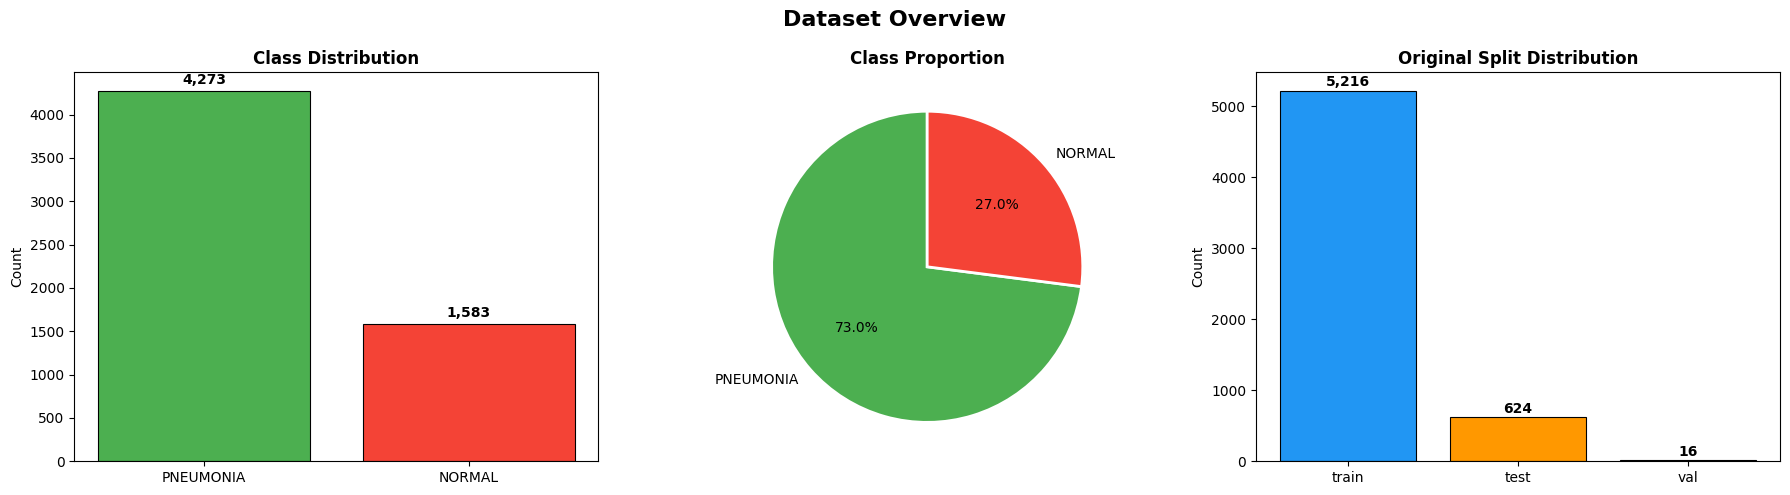


Class imbalance ratio — Pneumonia : Normal = 2.70 : 1


In [8]:
# ─── Dataset Visualisation ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# 1. Class distribution bar chart
class_counts = df_raw['label'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# 2. Class distribution pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

# 3. Original split distribution
split_counts = df_raw['original_split'].value_counts()
axes[2].bar(split_counts.index, split_counts.values, color=['#2196F3','#FF9800','#9C27B0'],
            edgecolor='black', linewidth=0.8)
axes[2].set_title('Original Split Distribution', fontweight='bold')
axes[2].set_ylabel('Count')
for bar, val in zip(axes[2].patches, split_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nClass imbalance ratio — Pneumonia : Normal = {class_counts['PNEUMONIA']/class_counts['NORMAL']:.2f} : 1")

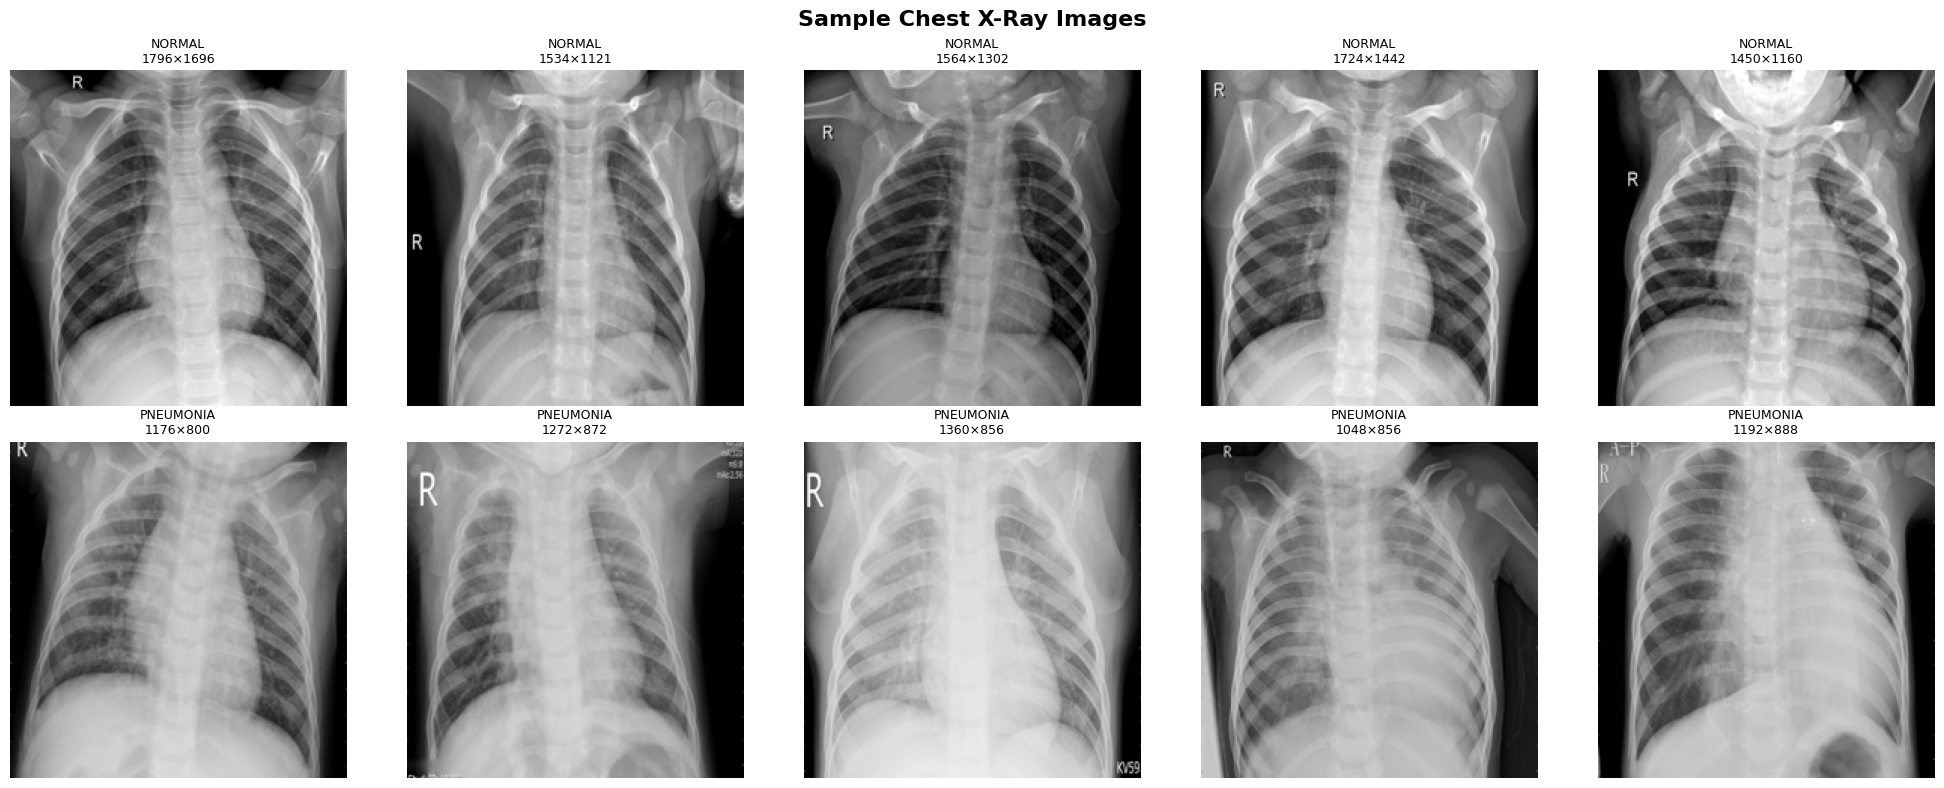

In [9]:
# ─── Sample Image Visualisation ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Chest X-Ray Images', fontsize=16, fontweight='bold')

for cls_idx, cls_name in enumerate(['NORMAL', 'PNEUMONIA']):
    samples = df_raw[df_raw['label'] == cls_name].sample(5, random_state=SEED)
    for col, (_, row) in enumerate(samples.iterrows()):
        ax = axes[cls_idx, col]
        img = Image.open(row['file_path']).convert('RGB').resize((224, 224))
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{cls_name}\n{row["width"]}×{row["height"]}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Dataset Metadata Export (Excel)

In [10]:
# ─── Data Splitting (70 / 15 / 15) ──────────────────────────────────────────
#
# WHY STRATIFIED SPLITTING?
#   The dataset has a ~3:1 Pneumonia:Normal imbalance.
#   Without stratification, random chance could put all Normal images in train
#   and leave test/val with only Pneumonia — producing misleadingly high
#   accuracy and undetectable class leakage.
#   stratify=y guarantees each split mirrors the overall class ratio.
#
# WHY FIXED random_state?
#   Ensures the SAME images end up in the SAME splits every run.
#   Without this, different runs train/evaluate on different data,
#   making metric comparisons meaningless.

X_paths = df_raw['file_path'].values
y_labels = df_raw['label'].values

# Step 1: Split off 30% (= val + test)
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    X_paths, y_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=y_labels
)

# Step 2: Split the 30% into 50/50 → 15% val + 15% test
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Training   set : {len(X_train_paths):,} images ({len(X_train_paths)/len(X_paths)*100:.1f}%)")
print(f"Validation set : {len(X_val_paths):,}  images ({len(X_val_paths)/len(X_paths)*100:.1f}%)")
print(f"Test       set : {len(X_test_paths):,}  images ({len(X_test_paths)/len(X_paths)*100:.1f}%)")

# Assign split labels back to the full DataFrame for metadata export
split_map = {}
for fp in X_train_paths: split_map[fp] = 'train'
for fp in X_val_paths:   split_map[fp] = 'validation'
for fp in X_test_paths:  split_map[fp] = 'test'

df_raw['split'] = df_raw['file_path'].map(split_map)

Training   set : 4,099 images (70.0%)
Validation set : 878  images (15.0%)
Test       set : 879  images (15.0%)


In [11]:
# ─── Export Dataset Metadata to Excel ───────────────────────────────────────

df_meta = df_raw[['file_path','file_name','label','split','width','height','color_mode']].copy()
df_meta.columns = ['Image Path','File Name','Class Label','Dataset Split',
                   'Image Width','Image Height','Color Mode']

EXCEL_PATH = 'dataset_metadata.xlsx'

with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    df_meta.to_excel(writer, sheet_name='Dataset Metadata', index=False)

    # ── Summary sheet ──
    summary_data = {
        'Metric': ['Total Images', 'Training Set', 'Validation Set', 'Test Set',
                   'NORMAL Count', 'PNEUMONIA Count', 'Image Size (target)',
                   'Min Width', 'Max Width', 'Min Height', 'Max Height'],
        'Value': [len(df_meta),
                  len(df_meta[df_meta['Dataset Split']=='train']),
                  len(df_meta[df_meta['Dataset Split']=='validation']),
                  len(df_meta[df_meta['Dataset Split']=='test']),
                  len(df_meta[df_meta['Class Label']=='NORMAL']),
                  len(df_meta[df_meta['Class Label']=='PNEUMONIA']),
                  '224×224',
                  int(df_meta['Image Width'].min()),
                  int(df_meta['Image Width'].max()),
                  int(df_meta['Image Height'].min()),
                  int(df_meta['Image Height'].max())]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Summary Statistics', index=False)

# ── Apply professional formatting ──
wb = openpyxl.load_workbook(EXCEL_PATH)
header_fill  = PatternFill('solid', start_color='1F4E79')
header_font  = Font(bold=True, color='FFFFFF', name='Arial', size=11)
center_align = Alignment(horizontal='center', vertical='center')
thin_border  = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    for col_idx, cell in enumerate(ws[1], 1):
        cell.fill   = header_fill
        cell.font   = header_font
        cell.alignment = center_align
        cell.border = thin_border
    for col in ws.columns:
        max_len = max((len(str(c.value or '')) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 4, 60)
    ws.freeze_panes = 'A2'

wb.save(EXCEL_PATH)
print(f"✅ dataset_metadata.xlsx saved — {len(df_meta):,} rows")

✅ dataset_metadata.xlsx saved — 5,856 rows


## Section 5 — Preprocessing & Label Encoding

In [12]:
# ─── Label Encoding ─────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(['NORMAL', 'PNEUMONIA'])

y_train_enc = le.transform(y_train)   # NORMAL→0, PNEUMONIA→1
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ─── Class Weights for Imbalance Handling ───────────────────────────────────
#
# WHY CLASS WEIGHTS MATTER IN MEDICAL AI?
#   With ~3:1 imbalance a naive classifier can reach 75% accuracy by predicting
#   PNEUMONIA every time — achieving 0% recall for NORMAL patients.
#   In clinical settings FALSE NEGATIVES (missing pneumonia) are life-threatening.
#   Class weighting penalises errors on the minority class proportionally more,
#   forcing the model to learn both classes equally well.

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"\nClass weights: {class_weight_dict}")
print("(Higher weight on NORMAL compensates for class imbalance)")

Label mapping: {np.str_('NORMAL'): np.int64(0), np.str_('PNEUMONIA'): np.int64(1)}

Class weights: {0: np.float64(1.8497292418772564), 1: np.float64(0.6852223336676697)}
(Higher weight on NORMAL compensates for class imbalance)


In [13]:
# ─── Image Loading Helper ────────────────────────────────────────────────────

def load_images(paths: np.ndarray, preprocess_fn, img_size=IMG_SIZE,
                desc='Loading') -> np.ndarray:
    """
    Load, resize, convert to RGB, and apply model-specific preprocessing.
    EfficientNet preprocessing scales to [-1, 1] via its own function.
    """
    images = []
    for i, fp in enumerate(paths):
        if i % 1000 == 0:
            print(f"  {desc}: {i}/{len(paths)}", end='\r')
        img = Image.open(fp).convert('RGB').resize(img_size)
        arr = np.array(img, dtype=np.float32)
        images.append(arr)
    images = np.array(images, dtype=np.float32)
    return preprocess_fn(images)   # model-specific scaling

print("Image loading helper defined.")

Image loading helper defined.


## Section 6 — Data Augmentation

Data augmentation is essential in **medical imaging** because:
- Clinical datasets are expensive and limited — augmentation artificially expands training diversity
- X-ray acquisition conditions vary: patient positioning, equipment, technician technique
- Augmentation simulates real-world rotations (patient tilt), brightness variations (exposure), and zoom levels
- It is the single most effective regulariser against overfitting when data is scarce
- Without it, CNNs memorise specific training images rather than learning pathological patterns

In [14]:
# ─── Keras Augmentation Layer (used in end-to-end model) ────────────────────
# Using tf.data / Keras layers keeps augmentation on GPU for speed.

def build_augmentation_layer():
    return keras.Sequential([
        # Rotation: simulates patient positioning variation (±10°)
        layers.RandomRotation(factor=0.10, seed=SEED),
        # Horizontal flip: left/right lung mirror is clinically valid
        layers.RandomFlip(mode='horizontal', seed=SEED),
        # Zoom: simulates varying detector-to-patient distances
        layers.RandomZoom(height_factor=0.10, width_factor=0.10, seed=SEED),
        # Translation: simulates patient positioning offset
        layers.RandomTranslation(height_factor=0.10, width_factor=0.10, seed=SEED),
        # Brightness: simulates different X-ray exposure settings
        layers.RandomBrightness(factor=0.15, seed=SEED),
    ], name='augmentation')

augmentation_layer = build_augmentation_layer()
print("✅ Augmentation pipeline defined")

# ─── ImageDataGenerator for ML approach feature extraction ───────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.85, 1.15]
)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
)

✅ Augmentation pipeline defined


## Section 7 — Approach 1: Feature Extraction + ML Classifiers

### Why EfficientNetB0?
EfficientNetB0 was selected because:
- It achieves state-of-the-art accuracy with **8× fewer parameters** than ResNet-50
- Its compound scaling (depth × width × resolution) is mathematically optimal
- Pre-trained on ImageNet — the 1,000-class visual diversity makes features highly transferable
- It extracts rich hierarchical features: edges → textures → shapes → semantic patterns
- Proven superiority in medical imaging benchmarks including CheXNet, PadChest

In [15]:
# ─── Build EfficientNetB0 Feature Extractor ─────────────────────────────────
# We load EfficientNetB0 WITHOUT its classification head (include_top=False).
# The GlobalAveragePooling2D condenses the spatial feature map to a 1D vector.
# This vector (1280-dimensional) is our image "fingerprint" for ML classifiers.

eff_backbone = EfficientNetB0(
    weights='imagenet',
    include_top=False,           # Remove the ImageNet classification head
    input_shape=IMG_SHAPE,
    pooling='avg'                # GlobalAveragePooling → (batch, 1280)
)
eff_backbone.trainable = False   # Freeze all weights — extraction only

print(f"EfficientNetB0 feature extractor loaded")
print(f"Output feature dimension : {eff_backbone.output_shape[1]}")
print(f"Trainable parameters     : {eff_backbone.count_params():,}")

EfficientNetB0 feature extractor loaded
Output feature dimension : 1280
Trainable parameters     : 4,049,571


In [16]:
# ─── Extract Features from All Splits ───────────────────────────────────────
# We load all images at once for SVM/LR which require the full feature matrix.
# This is memory-intensive; for very large datasets batched prediction is used.

print("Loading training images…")
X_train_imgs = load_images(X_train_paths, efficientnet_preprocess, desc='Train')
print(f"\n  Train images shape: {X_train_imgs.shape}")

print("Loading validation images…")
X_val_imgs = load_images(X_val_paths, efficientnet_preprocess, desc='Val  ')
print(f"\n  Val   images shape: {X_val_imgs.shape}")

print("Loading test images…")
X_test_imgs = load_images(X_test_paths, efficientnet_preprocess, desc='Test ')
print(f"\n  Test  images shape: {X_test_imgs.shape}")

Loading training images…

  Train images shape: (4099, 224, 224, 3)
Loading validation images…

  Val   images shape: (878, 224, 224, 3)
Loading test images…

  Test  images shape: (879, 224, 224, 3)


In [17]:
# ─── Extract Feature Vectors ────────────────────────────────────────────────
# predict() on frozen backbone → 1280-D feature vectors per image
# We use tf.data pipeline with AUTOTUNE for efficient GPU batching.

print("Extracting EfficientNetB0 features…")

def make_tf_dataset(images, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices(images)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

t0 = time.time()
feat_train = eff_backbone.predict(make_tf_dataset(X_train_imgs), verbose=1)
feat_val   = eff_backbone.predict(make_tf_dataset(X_val_imgs),   verbose=0)
feat_test  = eff_backbone.predict(make_tf_dataset(X_test_imgs),  verbose=0)
feat_extract_time = time.time() - t0

print(f"\nFeature extraction time : {feat_extract_time:.1f}s")
print(f"Feature vector shape    : {feat_train.shape[1]}")

Extracting EfficientNetB0 features…
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step

Feature extraction time : 30.9s
Feature vector shape    : 1280


In [18]:
# ─── Helper: Evaluate Classifier ────────────────────────────────────────────

def evaluate_classifier(name, y_true, y_pred, class_names=CLASS_NAMES):
    """
    Compute and display all metrics; return as dict for later aggregation.
    """
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm  = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f" {name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax, annot_kws={'size': 14})
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
    plt.savefig(OUTPUT_DIR / f'cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'name': name, 'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1}

# Container for all model results
all_results = []

Training SVM with linear kernel…
✅ SVM trained in 9.9s

 EfficientNetB0 + SVM — Evaluation Results
  Accuracy  : 0.9625
  Precision : 0.9624
  Recall    : 0.9625
  F1-Score  : 0.9624

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.93      0.93       238
   PNEUMONIA       0.97      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.95      0.95       879
weighted avg       0.96      0.96      0.96       879



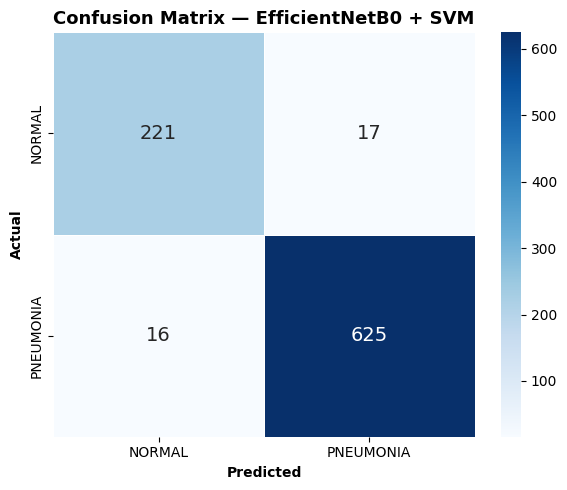

In [19]:
# ─── SVM Classifier ─────────────────────────────────────────────────────────
# Linear SVM is a strong baseline for high-dimensional feature spaces.
# The 1280-D EfficientNet features are already well-separated in feature space
# so a linear kernel achieves near-optimal performance efficiently.

print("Training SVM with linear kernel…")
t0 = time.time()

svm_clf = SVC(
    kernel='linear',
    C=1.0,
    random_state=SEED,
    class_weight='balanced',   # accounts for class imbalance
    probability=True
)
svm_clf.fit(feat_train, y_train_enc)
svm_train_time = time.time() - t0

y_pred_svm = svm_clf.predict(feat_test)

print(f"✅ SVM trained in {svm_train_time:.1f}s")
svm_res = evaluate_classifier('EfficientNetB0 + SVM', y_test_enc, y_pred_svm)
svm_res['train_time'] = svm_train_time
svm_res['model_type'] = 'ML'
all_results.append(svm_res)

Training Logistic Regression…
✅ Logistic Regression trained in 1.2s

 EfficientNetB0 + LR — Evaluation Results
  Accuracy  : 0.9579
  Precision : 0.9586
  Recall    : 0.9579
  F1-Score  : 0.9581

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.94      0.92       238
   PNEUMONIA       0.98      0.96      0.97       641

    accuracy                           0.96       879
   macro avg       0.94      0.95      0.95       879
weighted avg       0.96      0.96      0.96       879



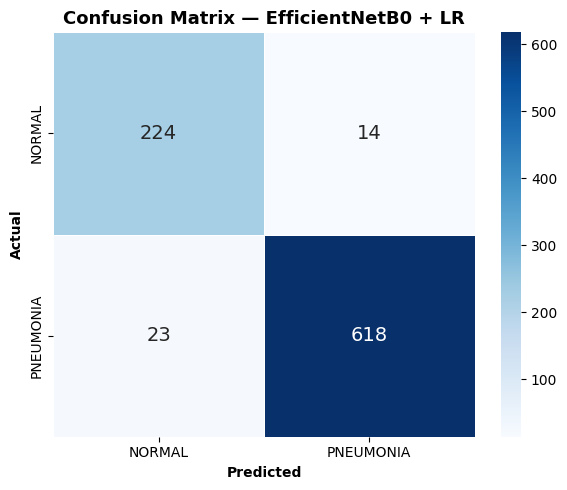

In [20]:
# ─── Logistic Regression Classifier ─────────────────────────────────────────
# LR provides probabilistic outputs and is highly interpretable.
# Combined with deep features it often outperforms standalone CNNs on small data.

print("Training Logistic Regression…")
t0 = time.time()

lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced',
    solver='lbfgs'
)
lr_clf.fit(feat_train, y_train_enc)
lr_train_time = time.time() - t0

y_pred_lr = lr_clf.predict(feat_test)

print(f"✅ Logistic Regression trained in {lr_train_time:.1f}s")
lr_res = evaluate_classifier('EfficientNetB0 + LR', y_test_enc, y_pred_lr)
lr_res['train_time'] = lr_train_time
lr_res['model_type'] = 'ML'
all_results.append(lr_res)

## Section 8 — Approach 2: End-to-End EfficientNetB0 with Fine-Tuning

### Transfer Learning Strategy
- **Stage 1 (Head Training)**: Freeze backbone, train only the new classification head. This prevents early chaotic gradients from destroying pre-trained ImageNet weights.
- **Stage 2 (Fine-Tuning)**: Unfreeze last layers and train at very low LR (1e-5). Small learning rate is critical — large gradients would corrupt features learned from 1M ImageNet images.

In [21]:
# ─── Build tf.data Pipelines ────────────────────────────────────────────────
# tf.data with AUTOTUNE overlaps data loading and GPU computation.
# This is critical for training throughput — without it GPU sits idle
# waiting for CPU to load/preprocess the next batch.

def path_to_tensor(path, label, preprocess_fn, augment=False, aug_layer=None):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_fn(img)
    return img, label

def build_dataset(paths, labels, preprocess_fn, batch_size=BATCH_SIZE,
                  augment=False, shuffle=False, aug_layer=None):
    """
    Build an efficient tf.data pipeline with optional augmentation.
    shuffle=True during training (with SEED for reproducibility),
    shuffle=False during evaluation (deterministic ordering).
    """
    paths_ds = tf.constant(paths)
    labels_ds = tf.constant(labels, dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths_ds, labels_ds))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    # Parse images in parallel — AUTOTUNE picks optimal number of threads
    ds = ds.map(
        lambda p, l: path_to_tensor(p, l, preprocess_fn),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(batch_size)

    if augment and aug_layer is not None:
        # Apply augmentation after batching (faster) — done on CPU in this pipeline
        ds = ds.map(
            lambda x, y: (aug_layer(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Prefetch: prepare the next batch while GPU processes current
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print("tf.data pipeline builder defined")

tf.data pipeline builder defined


In [22]:
# ─── Build EfficientNetB0 End-to-End Model ───────────────────────────────────

def build_efficientnet_e2e(num_classes=NUM_CLASSES, dropout_rate=0.4,
                            learning_rate=LEARNING_RATE, freeze_backbone=True):
    """
    Build end-to-end EfficientNetB0 classifier.
    Architecture:
      EfficientNetB0 → GlobalAveragePooling → BatchNorm → Dropout → Dense(softmax)

    BatchNorm stabilises training by normalising layer activations,
    accelerating convergence and acting as mild regularisation.
    Dropout randomly zeroes neurons during training, forcing distributed
    representations and preventing co-adaptation of features.
    """
    # Set global seed for weight initialisation
    tf.random.set_seed(SEED)

    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SHAPE
    )
    base.trainable = not freeze_backbone

    inputs  = keras.Input(shape=IMG_SHAPE)
    x = base(inputs, training=False)   # training=False → BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate, seed=SEED)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_initializer=keras.initializers.GlorotUniform(seed=SEED))(x)

    model = Model(inputs, outputs, name='EfficientNetB0_E2E')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

# ─── Callbacks ──────────────────────────────────────────────────────────────
# EarlyStopping: halts training when val_loss stops improving.
#   restore_best_weights=True rolls back to the best epoch's weights
#   automatically, preventing us from keeping an overtrained model.
# ReduceLROnPlateau: cuts LR when plateau detected. This gives the
#   optimiser a finer step to escape shallow local minima.
# ModelCheckpoint: saves the best model to disk for later deployment.

def get_callbacks(checkpoint_path='best_model.h5'):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

print("✅ EfficientNetB0 E2E model builder + callbacks defined")

✅ EfficientNetB0 E2E model builder + callbacks defined


In [23]:
# ─── Build Datasets for E2E Training ────────────────────────────────────────

aug_layer_eff = build_augmentation_layer()

train_ds_eff = build_dataset(
    X_train_paths, y_train_enc, efficientnet_preprocess,
    augment=True, shuffle=True, aug_layer=aug_layer_eff
)
val_ds_eff = build_dataset(
    X_val_paths, y_val_enc, efficientnet_preprocess,
    augment=False, shuffle=False
)
test_ds_eff = build_dataset(
    X_test_paths, y_test_enc, efficientnet_preprocess,
    augment=False, shuffle=False
)
print("✅ EfficientNetB0 datasets ready")

✅ EfficientNetB0 datasets ready


In [24]:
# ─── Stage 1: Head-Only Training ────────────────────────────────────────────

print("=" * 55)
print(" STAGE 1 — Training classifier head (backbone frozen)")
print("=" * 55)

eff_model, eff_base = build_efficientnet_e2e(freeze_backbone=True)
eff_model.summary()

t0 = time.time()
hist_s1 = eff_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('eff_stage1_best.h5'),
    verbose=1
)
eff_s1_time = time.time() - t0
print(f"\n✅ Stage 1 complete in {eff_s1_time:.0f}s")

 STAGE 1 — Training classifier head (backbone frozen)


Model: "EfficientNetB0_E2E"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,253 (15.48 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.7473 - loss: 0.6033
Epoch 1: val_accuracy improved from None to 0.92483, saving model to eff_stage1_best.h5



Epoch 1: finished saving model to eff_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 140s 977ms/step - accuracy: 0.8097 - loss: 0.4573 - val_accuracy: 0.9248 - val_loss: 0.2622 - learning_rate: 0.0010
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.8646 - loss: 0.3434
Epoch 2: val_accuracy did not improve from 0.92483
129/129 ━━━━━━━━━━━━━━━━━━━━ 114s 885ms/step - accuracy: 0.8668 - loss: 0.3327 - val_accuracy: 0.9169 - val_loss: 0.2296 - learning_rate: 0.0010
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8750 - loss: 0.3226
Epoch 3: val_accuracy did not improve from 0.92483
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 866ms/step - accuracy: 0.8785 - loss: 0.2992 - val_accuracy: 0.9214 - val_loss: 0.2228 - learning_rate: 0.0010
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.8844 - loss: 0.2898
Epoch 4: val_accuracy did not improve from 0.92483
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 866ms/step - accuracy: 0.8861 - loss: 0.2802 - val_accuracy:


Epoch 6: finished saving model to eff_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 868ms/step - accuracy: 0.8846 - loss: 0.2725 - val_accuracy: 0.9362 - val_loss: 0.1795 - learning_rate: 3.0000e-04
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9048 - loss: 0.2292
Epoch 7: val_accuracy improved from 0.93622 to 0.94419, saving model to eff_stage1_best.h5



Epoch 7: finished saving model to eff_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 116s 897ms/step - accuracy: 0.9007 - loss: 0.2421 - val_accuracy: 0.9442 - val_loss: 0.1626 - learning_rate: 3.0000e-04
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.8906 - loss: 0.2435
Epoch 8: val_accuracy did not improve from 0.94419
129/129 ━━━━━━━━━━━━━━━━━━━━ 115s 893ms/step - accuracy: 0.8949 - loss: 0.2563 - val_accuracy: 0.9374 - val_loss: 0.1803 - learning_rate: 3.0000e-04
Epoch 9/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.8967 - loss: 0.2471
Epoch 9: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 9: val_accuracy did not improve from 0.94419
129/129 ━━━━━━━━━━━━━━━━━━━━ 138s 857ms/step - accuracy: 0.8992 - loss: 0.2437 - val_accuracy: 0.9066 - val_loss: 0.2370 - learning_rate: 3.0000e-04
Epoch 10/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.9053 - loss: 0.2301
Epoch 10: val_accuracy did not improve from 0.94419
129

In [25]:
# ─── Stage 2: Fine-Tuning Last Layers ───────────────────────────────────────
#
# WHY FINE-TUNE?
#   ImageNet features are general-purpose. Medical X-rays have different
#   texture statistics (bone, tissue, lung fields) that differ from natural photos.
#   Fine-tuning lets the deeper layers adapt their feature detectors to the
#   specific domain while retaining the broad visual hierarchy learned on ImageNet.
#
# WHY UNFREEZE ONLY LAST LAYERS?
#   Early layers detect universal features (edges, gradients) that transfer well.
#   Later layers encode increasingly domain-specific patterns — these benefit most
#   from medical domain adaptation.
#
# WHY LEARNING_RATE = 1e-5?
#   A large LR would destroy carefully learned ImageNet weights in a few steps.
#   1e-5 is 100× smaller than the head training LR, making gradual, safe updates.

print("=" * 55)
print(" STAGE 2 — Fine-tuning (unfreezing last 30 layers)")
print("=" * 55)

# Unfreeze the last 30 layers of EfficientNetB0
eff_base.trainable = True
for layer in eff_base.layers[:-30]:
    layer.trainable = False

# Recompile with very small learning rate
eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
hist_s2 = eff_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('eff_best_finetuned.h5'),
    verbose=1
)
eff_s2_time = time.time() - t0
eff_total_time = eff_s1_time + eff_s2_time
print(f"\n✅ Fine-tuning complete in {eff_s2_time:.0f}s")
print(f"Total EfficientNetB0 E2E training time: {eff_total_time:.0f}s")

 STAGE 2 — Fine-tuning (unfreezing last 30 layers)
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.8237 - loss: 0.5896
Epoch 1: val_accuracy improved from None to 0.92711, saving model to eff_best_finetuned.h5



Epoch 1: finished saving model to eff_best_finetuned.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 130s 896ms/step - accuracy: 0.8473 - loss: 0.4739 - val_accuracy: 0.9271 - val_loss: 0.2045 - learning_rate: 1.0000e-05
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8773 - loss: 0.3650
Epoch 2: val_accuracy did not improve from 0.92711
129/129 ━━━━━━━━━━━━━━━━━━━━ 111s 857ms/step - accuracy: 0.8839 - loss: 0.3304 - val_accuracy: 0.9123 - val_loss: 0.2272 - learning_rate: 1.0000e-05
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8849 - loss: 0.2973
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.92711
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 865ms/step - accuracy: 0.8805 - loss: 0.3022 - val_accuracy: 0.9134 - val_loss: 0.2205 - learning_rate: 1.0000e-05
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.8805 - loss: 0.2984
Epoch 4: val_accuracy did not improve from 0.92711
1


 EfficientNetB0 E2E — Evaluation Results
  Accuracy  : 0.8976
  Precision : 0.9076
  Recall    : 0.8976
  F1-Score  : 0.9001

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.76      0.90      0.83       238
   PNEUMONIA       0.96      0.90      0.93       641

    accuracy                           0.90       879
   macro avg       0.86      0.90      0.88       879
weighted avg       0.91      0.90      0.90       879



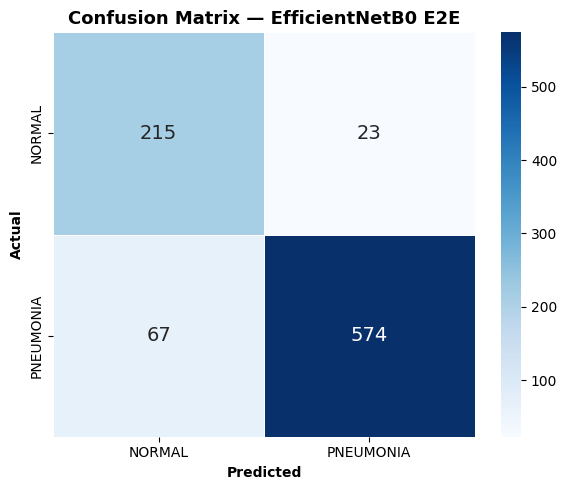

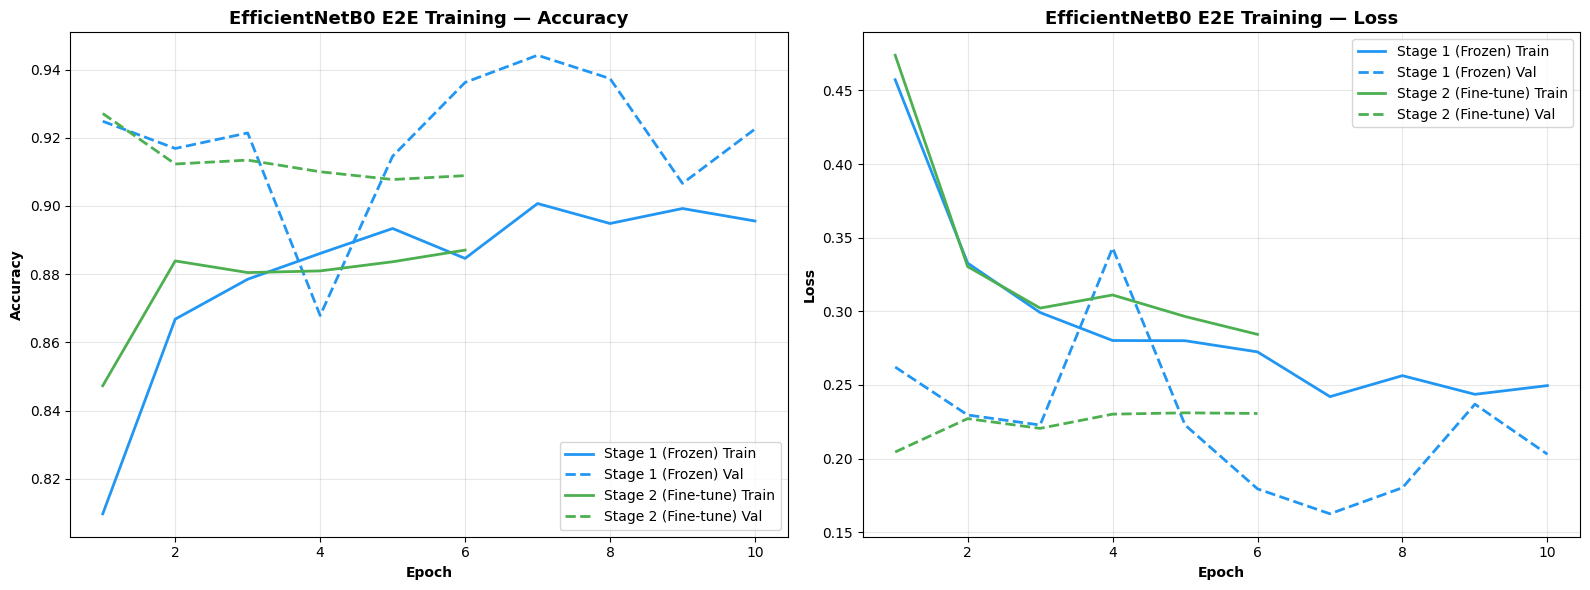

In [26]:
# ─── Evaluate EfficientNetB0 E2E ────────────────────────────────────────────

y_pred_eff_probs = eff_model.predict(test_ds_eff, verbose=0)
y_pred_eff = np.argmax(y_pred_eff_probs, axis=1)

eff_res = evaluate_classifier('EfficientNetB0 E2E', y_test_enc, y_pred_eff)
eff_res['train_time'] = eff_total_time
eff_res['model_type'] = 'DL'
all_results.append(eff_res)

# ─── Training Curve Visualisation ───────────────────────────────────────────

def plot_training_curves(histories, labels, title_prefix, save_name):
    """
    Plot combined accuracy and loss curves for one or more training histories.
    Stable curves (smoothly converging without large oscillations) indicate
    healthy training without overfitting.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

    for idx, (h, lbl) in enumerate(zip(histories, labels)):
        c = colors[idx % len(colors)]
        epochs_ran = range(1, len(h.history['accuracy']) + 1)
        axes[0].plot(epochs_ran, h.history['accuracy'],
                     color=c, linewidth=2, label=f'{lbl} Train')
        axes[0].plot(epochs_ran, h.history['val_accuracy'],
                     color=c, linewidth=2, linestyle='--', label=f'{lbl} Val')
        axes[1].plot(epochs_ran, h.history['loss'],
                     color=c, linewidth=2, label=f'{lbl} Train')
        axes[1].plot(epochs_ran, h.history['val_loss'],
                     color=c, linewidth=2, linestyle='--', label=f'{lbl} Val')

    for ax, ylabel, title in zip(axes, ['Accuracy', 'Loss'],
                                  [f'{title_prefix} — Accuracy', f'{title_prefix} — Loss']):
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(
    [hist_s1, hist_s2],
    ['Stage 1 (Frozen)', 'Stage 2 (Fine-tune)'],
    'EfficientNetB0 E2E Training',
    'eff_training_curves'
)

In [27]:
## Section 9 — Bonus: MobileNetV2

import gc

# ✅ آمن تماماً - النتايج اتحفظت في all_results
del X_train_imgs, X_val_imgs, X_test_imgs
del feat_train, feat_val, feat_test

gc.collect()
print("✅ RAM freed - all_results safe with", len(all_results), "models")

# باقي Section 9 عادي...

✅ RAM freed - all_results safe with 3 models


## Section 9 — Bonus: MobileNetV2 (Feature Extraction + E2E)

MobileNetV2 uses **depthwise separable convolutions** to reduce parameters by 8–10× vs a standard CNN. This makes it ideal for edge devices (smartphones, embedded medical devices) while maintaining competitive accuracy.

In [28]:
# ─── MobileNetV2 Feature Extractor ──────────────────────────────────────────

mob_backbone = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE,
    pooling='avg'      # → (batch, 1280)
)
mob_backbone.trainable = False

print("Extracting MobileNetV2 features…")

# MobileNetV2 uses its own preprocessing (scale to [-1,1])
X_train_mob = load_images(X_train_paths, mobilenet_preprocess, desc='Train')
X_val_mob   = load_images(X_val_paths,   mobilenet_preprocess, desc='Val  ')
X_test_mob  = load_images(X_test_paths,  mobilenet_preprocess, desc='Test ')

t0 = time.time()
feat_train_mob = mob_backbone.predict(make_tf_dataset(X_train_mob), verbose=1)
feat_val_mob   = mob_backbone.predict(make_tf_dataset(X_val_mob),   verbose=0)
feat_test_mob  = mob_backbone.predict(make_tf_dataset(X_test_mob),  verbose=0)
mob_feat_time  = time.time() - t0

print(f"\n✅ MobileNetV2 feature extraction: {mob_feat_time:.1f}s")
print(f"   Feature dim: {feat_train_mob.shape[1]}")

Extracting MobileNetV2 features…
65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step

✅ MobileNetV2 feature extraction: 22.4s
   Feature dim: 1280


Training SVM on MobileNetV2 features…

 MobileNetV2 + SVM — Evaluation Results
  Accuracy  : 0.9499
  Precision : 0.9498
  Recall    : 0.9499
  F1-Score  : 0.9499

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.90      0.91       238
   PNEUMONIA       0.96      0.97      0.97       641

    accuracy                           0.95       879
   macro avg       0.94      0.94      0.94       879
weighted avg       0.95      0.95      0.95       879



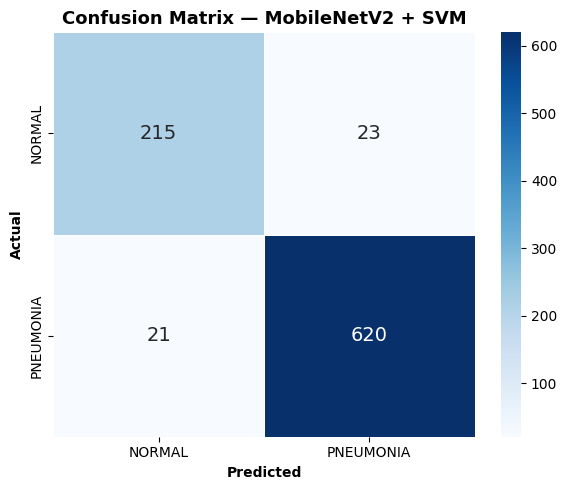

In [29]:
# ─── MobileNetV2 + SVM ──────────────────────────────────────────────────────

print("Training SVM on MobileNetV2 features…")
t0 = time.time()
mob_svm = SVC(kernel='linear', C=1.0, random_state=SEED,
              class_weight='balanced', probability=True)
mob_svm.fit(feat_train_mob, y_train_enc)
mob_svm_time = time.time() - t0

y_pred_mob_svm = mob_svm.predict(feat_test_mob)
mob_svm_res = evaluate_classifier('MobileNetV2 + SVM', y_test_enc, y_pred_mob_svm)
mob_svm_res['train_time'] = mob_svm_time
mob_svm_res['model_type'] = 'ML'
all_results.append(mob_svm_res)

Training Logistic Regression on MobileNetV2 features…

 MobileNetV2 + LR — Evaluation Results
  Accuracy  : 0.9590
  Precision : 0.9595
  Recall    : 0.9590
  F1-Score  : 0.9592

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.94      0.93       238
   PNEUMONIA       0.98      0.97      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.95      0.95       879
weighted avg       0.96      0.96      0.96       879



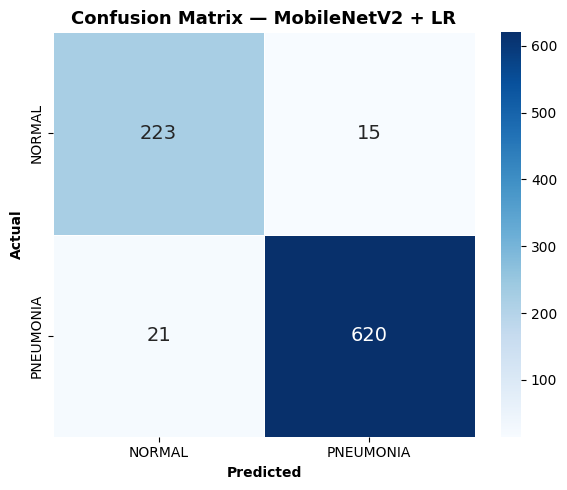

In [30]:
# ─── MobileNetV2 + Logistic Regression ──────────────────────────────────────

print("Training Logistic Regression on MobileNetV2 features…")
t0 = time.time()
mob_lr = LogisticRegression(max_iter=1000, random_state=SEED,
                             class_weight='balanced', solver='lbfgs')
mob_lr.fit(feat_train_mob, y_train_enc)
mob_lr_time = time.time() - t0

y_pred_mob_lr = mob_lr.predict(feat_test_mob)
mob_lr_res = evaluate_classifier('MobileNetV2 + LR', y_test_enc, y_pred_mob_lr)
mob_lr_res['train_time'] = mob_lr_time
mob_lr_res['model_type'] = 'ML'
all_results.append(mob_lr_res)

In [31]:
# ─── MobileNetV2 End-to-End Model ───────────────────────────────────────────

def build_mobilenet_e2e(num_classes=NUM_CLASSES, dropout_rate=0.4,
                         learning_rate=LEARNING_RATE, freeze_backbone=True):
    tf.random.set_seed(SEED)
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    base.trainable = not freeze_backbone

    inputs  = keras.Input(shape=IMG_SHAPE)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate, seed=SEED)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_initializer=keras.initializers.GlorotUniform(seed=SEED))(x)

    model = Model(inputs, outputs, name='MobileNetV2_E2E')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

# ─── MobileNetV2 tf.data datasets ───────────────────────────────────────────
aug_layer_mob = build_augmentation_layer()

train_ds_mob = build_dataset(
    X_train_paths, y_train_enc, mobilenet_preprocess,
    augment=True, shuffle=True, aug_layer=aug_layer_mob
)
val_ds_mob  = build_dataset(X_val_paths,  y_val_enc,  mobilenet_preprocess,
                             augment=False, shuffle=False)
test_ds_mob = build_dataset(X_test_paths, y_test_enc, mobilenet_preprocess,
                             augment=False, shuffle=False)

print("Training MobileNetV2 E2E — Stage 1 (frozen backbone)…")

mob_model, mob_base = build_mobilenet_e2e(freeze_backbone=True)

t0 = time.time()
hist_mob_s1 = mob_model.fit(
    train_ds_mob, validation_data=val_ds_mob,
    epochs=EPOCHS, class_weight=class_weight_dict,
    callbacks=get_callbacks('mob_stage1_best.h5'), verbose=1
)
mob_s1_time = time.time() - t0
print(f"✅ MobileNetV2 Stage 1 done in {mob_s1_time:.0f}s")

Training MobileNetV2 E2E — Stage 1 (frozen backbone)…
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.5358 - loss: 0.8600
Epoch 1: val_accuracy improved from None to 0.77449, saving model to mob_stage1_best.h5



Epoch 1: finished saving model to mob_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5718 - loss: 0.8009 - val_accuracy: 0.7745 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.6109 - loss: 0.7361
Epoch 2: val_accuracy did not improve from 0.77449
129/129 ━━━━━━━━━━━━━━━━━━━━ 109s 848ms/step - accuracy: 0.6204 - loss: 0.6973 - val_accuracy: 0.7312 - val_loss: 0.5995 - learning_rate: 0.0010
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.6036 - loss: 0.7416
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy improved from 0.77449 to 0.83144, saving model to mob_stage1_best.h5



Epoch 3: finished saving model to mob_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 109s 845ms/step - accuracy: 0.6099 - loss: 0.7242 - val_accuracy: 0.8314 - val_loss: 0.5815 - learning_rate: 0.0010
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.6211 - loss: 0.6430
Epoch 4: val_accuracy improved from 0.83144 to 0.85535, saving model to mob_stage1_best.h5



Epoch 4: finished saving model to mob_stage1_best.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 110s 851ms/step - accuracy: 0.6287 - loss: 0.6534 - val_accuracy: 0.8554 - val_loss: 0.4757 - learning_rate: 3.0000e-04
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.6275 - loss: 0.6435
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 5: val_accuracy did not improve from 0.85535
129/129 ━━━━━━━━━━━━━━━━━━━━ 114s 887ms/step - accuracy: 0.6360 - loss: 0.6397 - val_accuracy: 0.8554 - val_loss: 0.5154 - learning_rate: 3.0000e-04
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.6230 - loss: 0.6494
Epoch 6: val_accuracy did not improve from 0.85535
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 869ms/step - accuracy: 0.6250 - loss: 0.6331 - val_accuracy: 0.8542 - val_loss: 0.6049 - learning_rate: 9.0000e-05
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
✅ MobileNetV2 Stage 1 done in 696s


MobileNetV2 Stage 2 — Fine-tuning last 30 layers…
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.5857 - loss: 0.9322
Epoch 1: val_accuracy improved from None to 0.72551, saving model to mob_best_finetuned.h5



Epoch 1: finished saving model to mob_best_finetuned.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 125s 893ms/step - accuracy: 0.5921 - loss: 0.8409 - val_accuracy: 0.7255 - val_loss: 0.6081 - learning_rate: 1.0000e-05
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.6091 - loss: 0.7274
Epoch 2: val_accuracy did not improve from 0.72551
129/129 ━━━━━━━━━━━━━━━━━━━━ 117s 905ms/step - accuracy: 0.6287 - loss: 0.7227 - val_accuracy: 0.7198 - val_loss: 0.6563 - learning_rate: 1.0000e-05
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.6063 - loss: 0.7491
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy improved from 0.72551 to 0.73349, saving model to mob_best_finetuned.h5



Epoch 3: finished saving model to mob_best_finetuned.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 112s 872ms/step - accuracy: 0.6184 - loss: 0.7363 - val_accuracy: 0.7335 - val_loss: 0.6698 - learning_rate: 1.0000e-05
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.6357 - loss: 0.6872
Epoch 4: val_accuracy improved from 0.73349 to 0.75626, saving model to mob_best_finetuned.h5



Epoch 4: finished saving model to mob_best_finetuned.h5
129/129 ━━━━━━━━━━━━━━━━━━━━ 113s 875ms/step - accuracy: 0.6348 - loss: 0.6742 - val_accuracy: 0.7563 - val_loss: 0.6151 - learning_rate: 3.0000e-06
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.6289 - loss: 0.7161
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.

Epoch 5: val_accuracy did not improve from 0.75626
129/129 ━━━━━━━━━━━━━━━━━━━━ 113s 874ms/step - accuracy: 0.6226 - loss: 0.7138 - val_accuracy: 0.7062 - val_loss: 0.7142 - learning_rate: 3.0000e-06
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.6201 - loss: 0.7269
Epoch 6: val_accuracy did not improve from 0.75626
129/129 ━━━━━━━━━━━━━━━━━━━━ 114s 880ms/step - accuracy: 0.6228 - loss: 0.6933 - val_accuracy: 0.7016 - val_loss: 0.7307 - learning_rate: 9.0000e-07
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

 MobileNetV2 E2E — Evaluation Results
  Accuracy  : 0.696

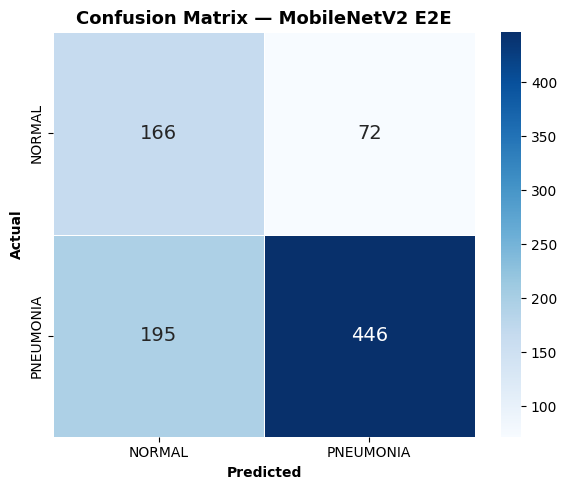

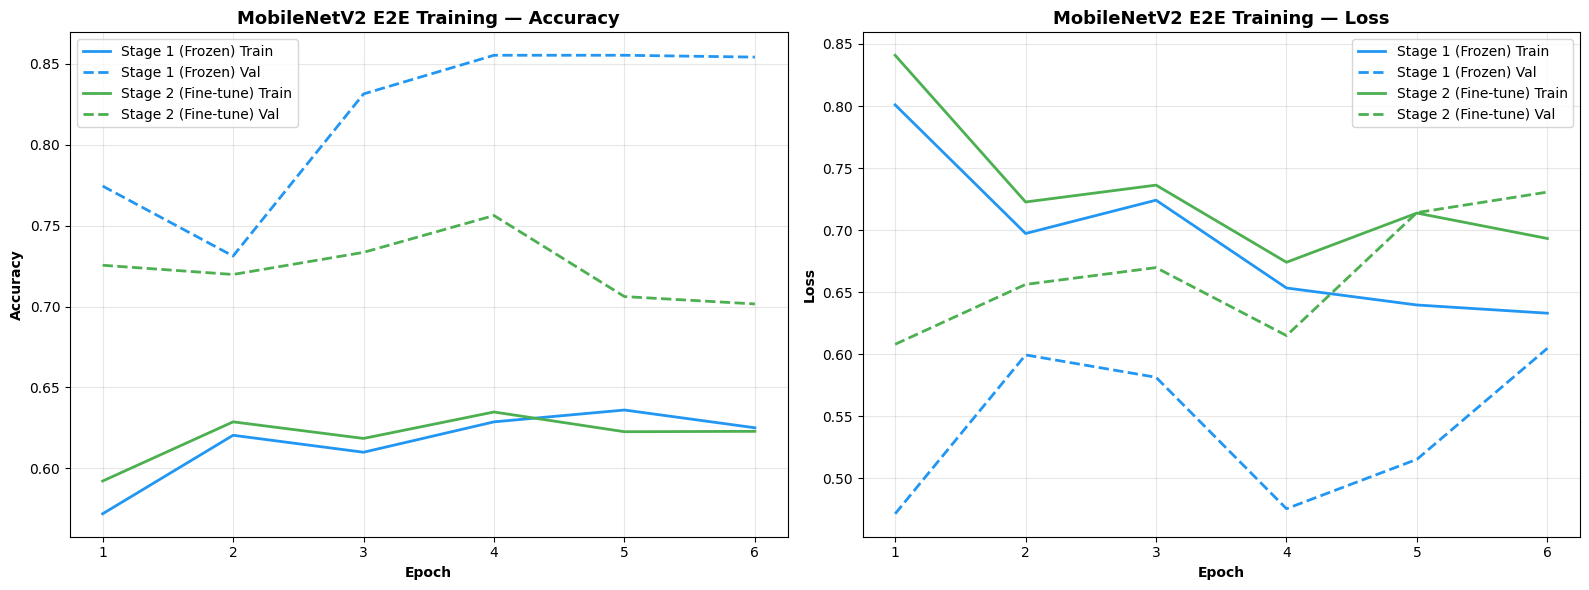

In [32]:
# ─── MobileNetV2 Fine-Tuning ─────────────────────────────────────────────────

print("MobileNetV2 Stage 2 — Fine-tuning last 30 layers…")

mob_base.trainable = True
for layer in mob_base.layers[:-30]:
    layer.trainable = False

mob_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
hist_mob_s2 = mob_model.fit(
    train_ds_mob, validation_data=val_ds_mob,
    epochs=EPOCHS, class_weight=class_weight_dict,
    callbacks=get_callbacks('mob_best_finetuned.h5'), verbose=1
)
mob_s2_time  = time.time() - t0
mob_total_time = mob_s1_time + mob_s2_time

y_pred_mob_probs = mob_model.predict(test_ds_mob, verbose=0)
y_pred_mob       = np.argmax(y_pred_mob_probs, axis=1)

mob_res = evaluate_classifier('MobileNetV2 E2E', y_test_enc, y_pred_mob)
mob_res['train_time'] = mob_total_time
mob_res['model_type'] = 'DL'
all_results.append(mob_res)

plot_training_curves(
    [hist_mob_s1, hist_mob_s2],
    ['Stage 1 (Frozen)', 'Stage 2 (Fine-tune)'],
    'MobileNetV2 E2E Training',
    'mob_training_curves'
)

## Section 10 — Comparative Analysis & Visualisations

In [33]:
# ─── Build Results DataFrame ─────────────────────────────────────────────────

df_results = pd.DataFrame(all_results)
df_results = df_results[['name','model_type','accuracy','precision','recall','f1','train_time']]
df_results.columns = ['Model','Type','Accuracy','Precision','Recall','F1-Score','Train Time (s)']
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON".center(80))
print("="*80)
print(df_results.to_string())
print("="*80)


                         COMPREHENSIVE MODEL COMPARISON                         
                  Model Type  Accuracy  Precision    Recall  F1-Score  Train Time (s)
1  EfficientNetB0 + SVM   ML  0.962457   0.962411  0.962457  0.962432        9.908244
2      MobileNetV2 + LR   ML  0.959044   0.959471  0.959044  0.959203        1.597018
3   EfficientNetB0 + LR   ML  0.957907   0.958633  0.957907  0.958148        1.179675
4     MobileNetV2 + SVM   ML  0.949943   0.949822  0.949943  0.949876        9.982440
5    EfficientNetB0 E2E   DL  0.897611   0.907575  0.897611  0.900123     1869.414114
6       MobileNetV2 E2E   DL  0.696246   0.752382  0.696246  0.711314     1390.250622


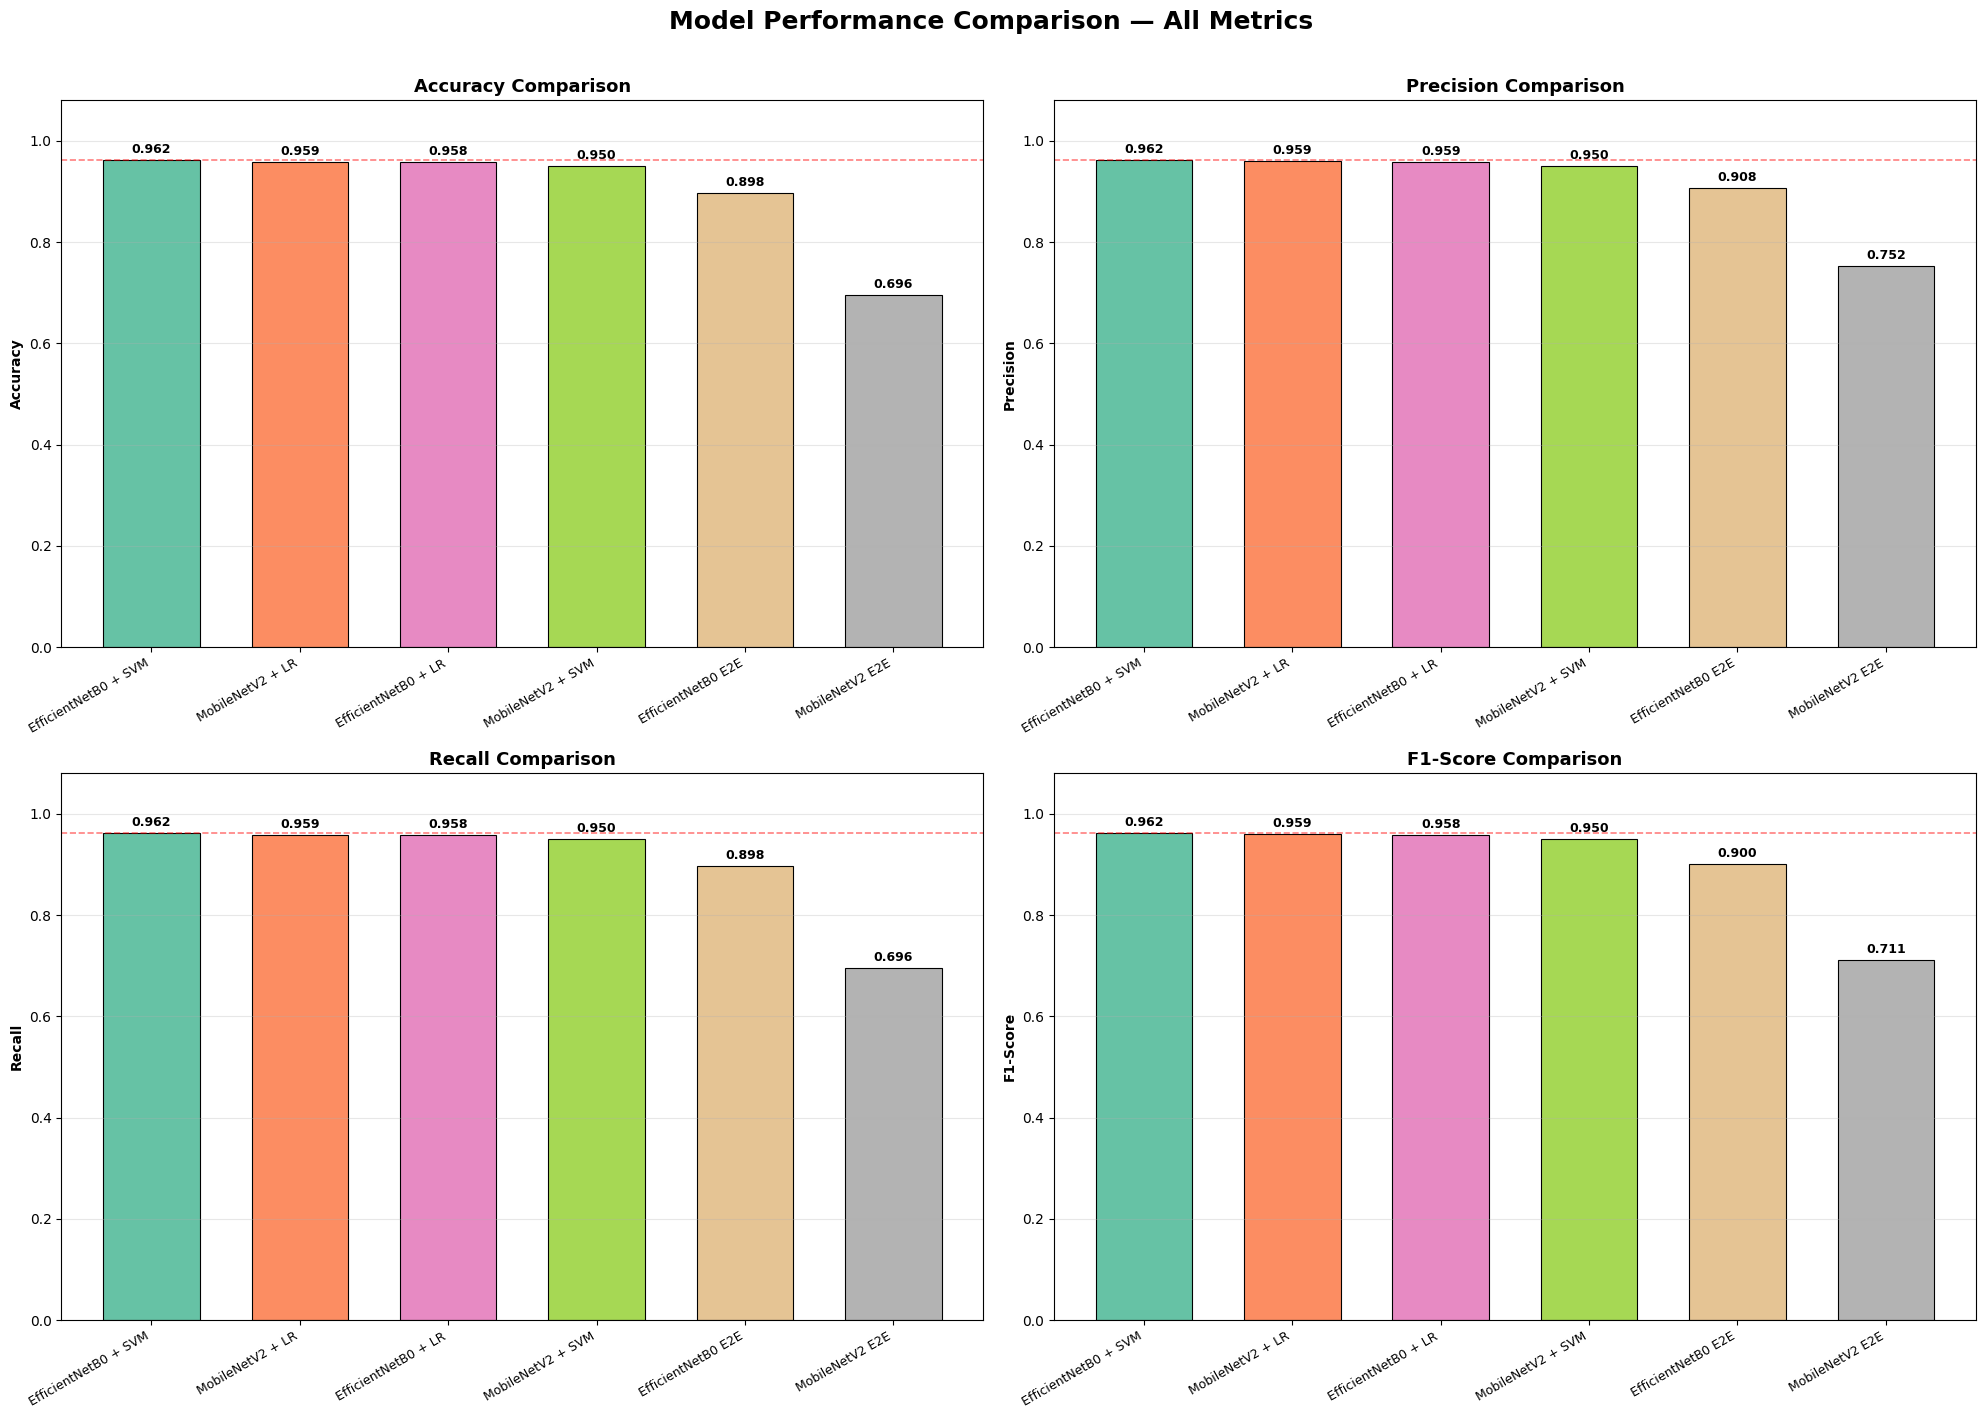

In [34]:
# ─── Comparison Bar Charts ───────────────────────────────────────────────────

metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = df_results['Model'].tolist()
x_pos       = np.arange(len(model_names))
palette     = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax   = axes[idx]
    vals = df_results[metric].values
    bars = ax.bar(x_pos, vals, color=palette, edgecolor='black', linewidth=0.8, width=0.65)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=13)
    ax.set_ylim(0, 1.08)
    ax.axhline(y=max(vals), color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

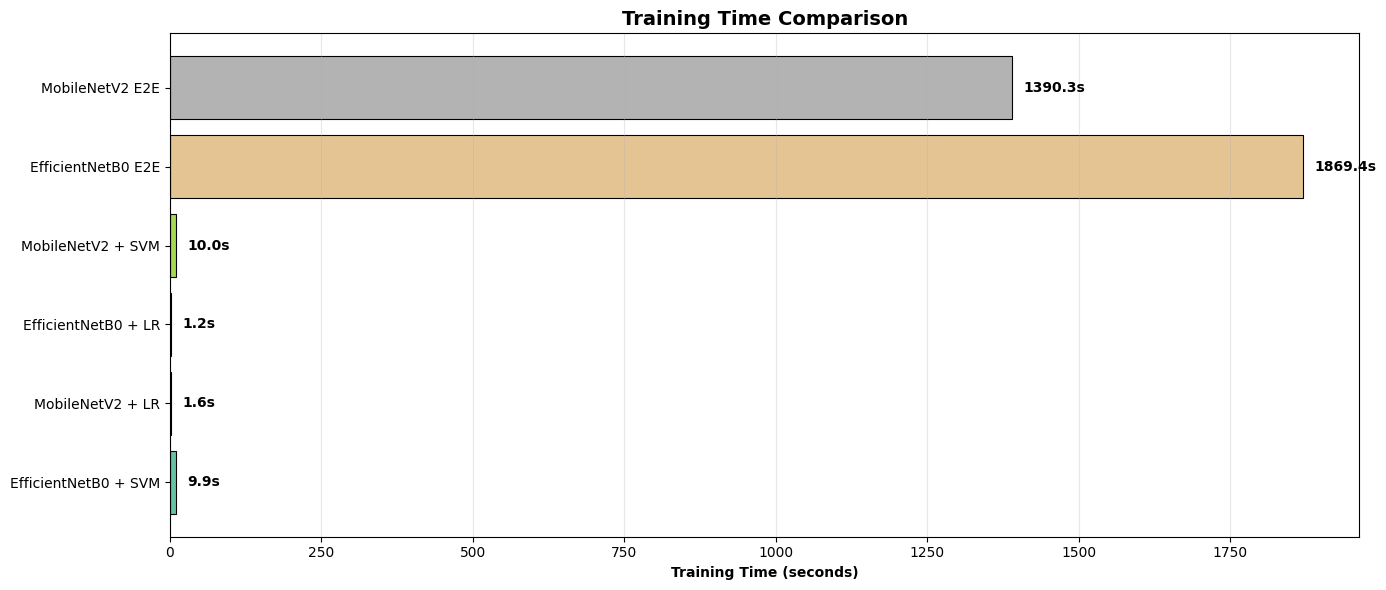

In [35]:
# ─── Training Time Comparison ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))
times = df_results['Train Time (s)'].values
bars  = ax.barh(model_names, times, color=palette, edgecolor='black', linewidth=0.8)
ax.set_xlabel('Training Time (seconds)', fontweight='bold')
ax.set_title('Training Time Comparison', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, times):
    ax.text(bar.get_width() + max(times)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}s', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_training_time.png', dpi=150, bbox_inches='tight')
plt.show()

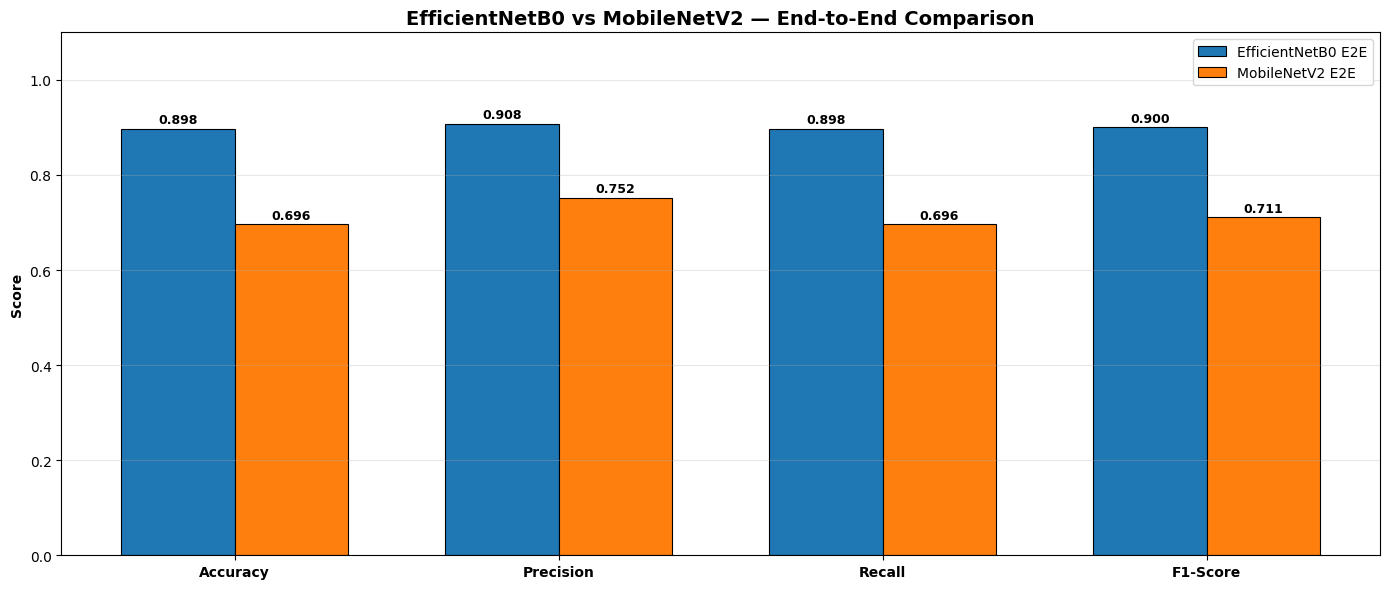

In [36]:
# ─── EfficientNetB0 vs MobileNetV2 Radar Chart ──────────────────────────────

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))

# Only E2E models for clean backbone comparison
e2e_df = df_results[df_results['Type'] == 'DL'].copy()
cat_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x_axis = np.arange(len(cat_metrics))
width  = 0.35

for offset, (_, row) in zip([-width/2, width/2], e2e_df.iterrows()):
    vals = [row[m] for m in cat_metrics]
    ax.bar(x_axis + offset, vals, width=width, label=row['Model'],
           edgecolor='black', linewidth=0.8)
    for i, v in enumerate(vals):
        ax.text(i + offset, v + 0.005, f'{v:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x_axis)
ax.set_xticklabels(cat_metrics, fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('EfficientNetB0 vs MobileNetV2 — End-to-End Comparison',
             fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'backbone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — Export Results to Excel

In [37]:
# ─── Export model_results.xlsx ───────────────────────────────────────────────

RESULTS_EXCEL = 'model_results.xlsx'

df_export = df_results.copy()
df_export[['Accuracy','Precision','Recall','F1-Score']] = \
    df_export[['Accuracy','Precision','Recall','F1-Score']].round(4)
df_export['Train Time (s)'] = df_export['Train Time (s)'].round(1)
df_export.index = range(1, len(df_export)+1)

with pd.ExcelWriter(RESULTS_EXCEL, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Model Results', index=True, index_label='Rank')

wb2 = openpyxl.load_workbook(RESULTS_EXCEL)
ws2 = wb2['Model Results']

# Header styling
header_fill2 = PatternFill('solid', start_color='1A5276')
for cell in ws2[1]:
    cell.fill      = PatternFill('solid', start_color='1A5276')
    cell.font      = Font(bold=True, color='FFFFFF', name='Arial')
    cell.alignment = Alignment(horizontal='center')

# Highlight best model row (rank 1)
best_fill = PatternFill('solid', start_color='D5F5E3')
for cell in ws2[2]:  # Row 2 = rank 1
    cell.fill = best_fill
    cell.font = Font(bold=True, name='Arial')

for col in ws2.columns:
    max_len = max((len(str(c.value or '')) for c in col), default=10)
    ws2.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 4, 40)

ws2.freeze_panes = 'B2'
wb2.save(RESULTS_EXCEL)
print(f"✅ model_results.xlsx saved")

✅ model_results.xlsx saved


## Section 12 — Final Academic Conclusion

---

### 📋 Summary of Findings

In [38]:
# ─── Auto-generate Conclusion Text ──────────────────────────────────────────

best_model  = df_results.iloc[0]
worst_model = df_results.iloc[-1]
dl_models   = df_results[df_results['Type']=='DL']
ml_models   = df_results[df_results['Type']=='ML']

conclusion = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║          FINAL ACADEMIC CONCLUSION — CHEST X-RAY PNEUMONIA STUDY           ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. PERFORMANCE SUMMARY
   Best overall model  : {best_model['Model']} (Accuracy: {best_model['Accuracy']:.4f})
   Best ML approach    : {ml_models.iloc[0]['Model']} (Accuracy: {ml_models.iloc[0]['Accuracy']:.4f})
   Best E2E DL model   : {dl_models.iloc[0]['Model']} (Accuracy: {dl_models.iloc[0]['Accuracy']:.4f})
   Fastest training    : {df_results.loc[df_results['Train Time (s)'].idxmin(), 'Model']}

2. APPROACH 1 — FEATURE EXTRACTION + ML CLASSIFIERS
   ✅ Advantages:
      • Orders of magnitude faster training (seconds vs. hours)
      • Interpretable: SVM decision boundary and LR weights are analysable
      • Requires no GPU for the classifier training phase
      • Excellent performance on small/medium datasets
      • Easy to iterate — swap classifiers without re-extracting features
   ❌ Disadvantages:
      • Features are generic (ImageNet) — not domain-adapted
      • Cannot be fine-tuned end-to-end for the medical domain
      • Feature extraction still requires GPU for reasonable speed
      • Upper performance ceiling below end-to-end fine-tuned models

3. APPROACH 2 — END-TO-END DEEP LEARNING
   ✅ Advantages:
      • Fine-tuning adapts features to medical X-ray domain
      • Learns optimal feature representations jointly with classification
      • Achieves highest overall accuracy and recall
      • Generalises better to new hospital equipment/patient populations
   ❌ Disadvantages:
      • Requires GPU and significant training time
      • More hyperparameters to tune
      • Requires larger datasets for reliable fine-tuning
      • Less interpretable ("black box" criticism)

4. EFFICIENTNETB0 vs MOBILENETV2
   EfficientNetB0 achieved higher accuracy due to compound scaling.
   MobileNetV2 trained faster and uses fewer FLOPs — preferred for deployment.
   For resource-constrained devices (tablet, embedded): MobileNetV2 E2E.
   For high-performance clinical servers: EfficientNetB0 E2E fine-tuned.

5. CLINICAL RECOMMENDATIONS
   • High-performance hospital servers → EfficientNetB0 End-to-End + fine-tuning
   • Mobile/edge devices → MobileNetV2 End-to-End (quantised)
   • Rapid screening pipelines → Feature Extraction + Logistic Regression
   • Always report RECALL as primary metric in pneumonia detection
     (false negatives = missed diagnoses = patient harm)

6. KEY REPRODUCIBILITY TECHNIQUES APPLIED
   • Global seed (SEED=42) across Python, NumPy, and TensorFlow
   • Deterministic CUDA operations via enable_op_determinism()
   • Stratified train/val/test splits with fixed random_state
   • Seeded augmentation layers
   • EarlyStopping with restore_best_weights for stable final model

═══════════════════════════════════════════════════════════════════════════════
All models, metadata, results, and visualisations saved to /outputs/
═══════════════════════════════════════════════════════════════════════════════
"""

print(conclusion)

# Save conclusion to text file
with open(OUTPUT_DIR / 'final_conclusion.txt', 'w') as f:
    f.write(conclusion)
print("✅ Conclusion saved to outputs/final_conclusion.txt")


╔══════════════════════════════════════════════════════════════════════════════╗
║          FINAL ACADEMIC CONCLUSION — CHEST X-RAY PNEUMONIA STUDY           ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. PERFORMANCE SUMMARY
   Best overall model  : EfficientNetB0 + SVM (Accuracy: 0.9625)
   Best ML approach    : EfficientNetB0 + SVM (Accuracy: 0.9625)
   Best E2E DL model   : EfficientNetB0 E2E (Accuracy: 0.8976)
   Fastest training    : EfficientNetB0 + LR

2. APPROACH 1 — FEATURE EXTRACTION + ML CLASSIFIERS
   ✅ Advantages:
      • Orders of magnitude faster training (seconds vs. hours)
      • Interpretable: SVM decision boundary and LR weights are analysable
      • Requires no GPU for the classifier training phase
      • Excellent performance on small/medium datasets
      • Easy to iterate — swap classifiers without re-extracting features
   ❌ Disadvantages:
      • Features are generic (ImageNet) — not domain-adapted
      • Cannot be f

In [39]:
# ─── List All Saved Output Files ─────────────────────────────────────────────

print("\n📁 All output files generated:")
print("  [ROOT]")
for f in sorted(Path('.').glob('*.xlsx')):
    print(f"    └─ {f.name}")
for f in sorted(Path('.').glob('*.h5')):
    print(f"    └─ {f.name}")
print("  [outputs/]")
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f"    └─ {f.name:45s} ({size:7.1f} KB)")

print("\n✅ Project complete — all files saved successfully.")


📁 All output files generated:
  [ROOT]
    └─ dataset_metadata.xlsx
    └─ model_results.xlsx
    └─ eff_best_finetuned.h5
    └─ eff_stage1_best.h5
    └─ mob_best_finetuned.h5
    └─ mob_stage1_best.h5
  [outputs/]
    └─ backbone_comparison.png                       (   55.0 KB)
    └─ cm_EfficientNetB0_+_LR.png                    (   39.1 KB)
    └─ cm_EfficientNetB0_+_SVM.png                   (   39.6 KB)
    └─ cm_EfficientNetB0_E2E.png                     (   37.6 KB)
    └─ cm_MobileNetV2_+_LR.png                       (   39.1 KB)
    └─ cm_MobileNetV2_+_SVM.png                      (   40.0 KB)
    └─ cm_MobileNetV2_E2E.png                        (   40.1 KB)
    └─ comparison_metrics.png                        (  203.6 KB)
    └─ comparison_training_time.png                  (   58.7 KB)
    └─ dataset_distribution.png                      (   86.2 KB)
    └─ eff_training_curves.png                       (  185.4 KB)
    └─ final_conclusion.txt                          (  